In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('27-mall_customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
df.drop(columns = 'CustomerID' , axis = 1 , inplace = True)

from sklearn.preprocessing import LabelEncoder 

encoder = LabelEncoder()

df['Gender'] = encoder.fit_transform(df['Gender'])

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [5]:
import math

def plot_histograms(df) : 

    sns.set_style('whitegrid')

    n_plots = len(df.columns)
    n_cols = 3 
    n_rows = math.ceil(n_plots / n_cols)

    fig , axes = plt.subplots(nrows = n_rows , ncols = n_cols , figsize = (18 , 5 * n_rows))

    axes = axes.flatten()

    for i , col in enumerate(df.columns) : 
        sns.histplot(data = df , x = col , ax = axes[i] , kde = True ,bins = 30 , color = '#4C72B0')
        axes[i].set_title(f'{col} Distribution')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Freq')

    for j in range(i+1 , len(axes)) : 
        plt.delaxes(axes[j])

    plt.tight_layout()

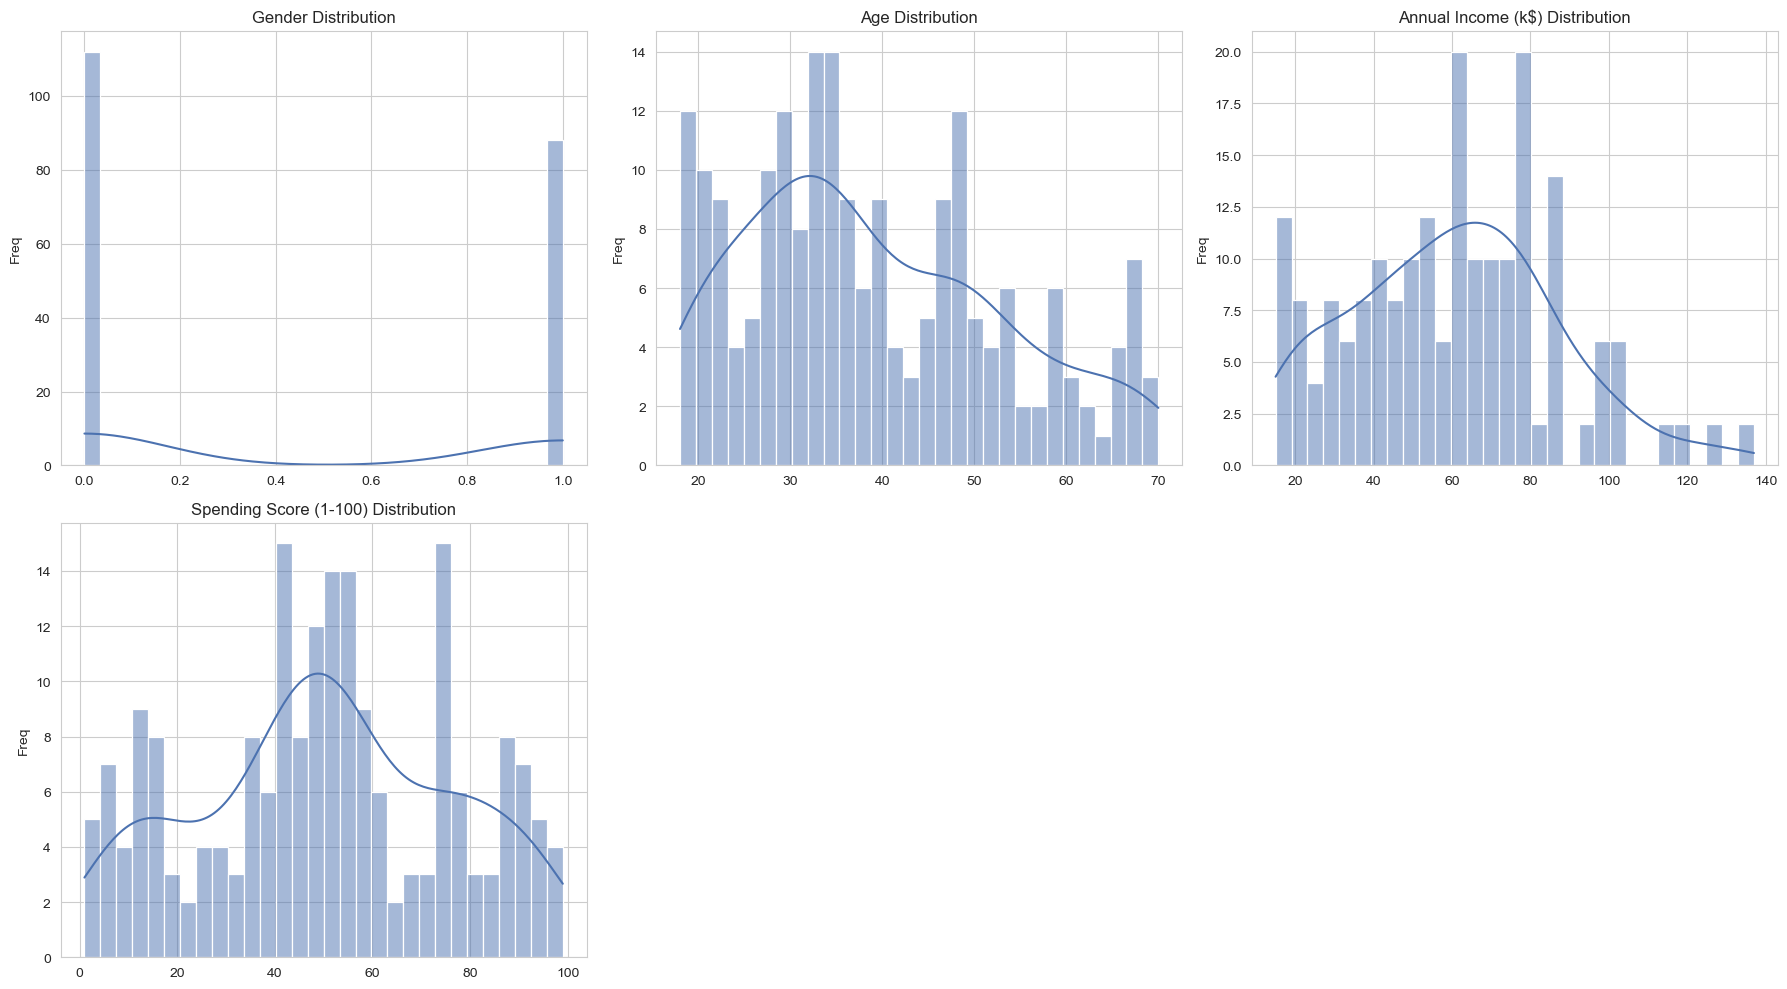

In [6]:
plot_histograms(df)

In [7]:
from sklearn.preprocessing import MinMaxScaler

In [8]:
scaler = MinMaxScaler()

df_scaled = scaler.fit_transform(df)

In [9]:
df = pd.DataFrame(df_scaled , columns = df.columns)

In [10]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1.0,0.019231,0.000000,0.387755
1,1.0,0.057692,0.000000,0.816327
2,0.0,0.038462,0.008197,0.051020
3,0.0,0.096154,0.008197,0.775510
4,0.0,0.250000,0.016393,0.397959


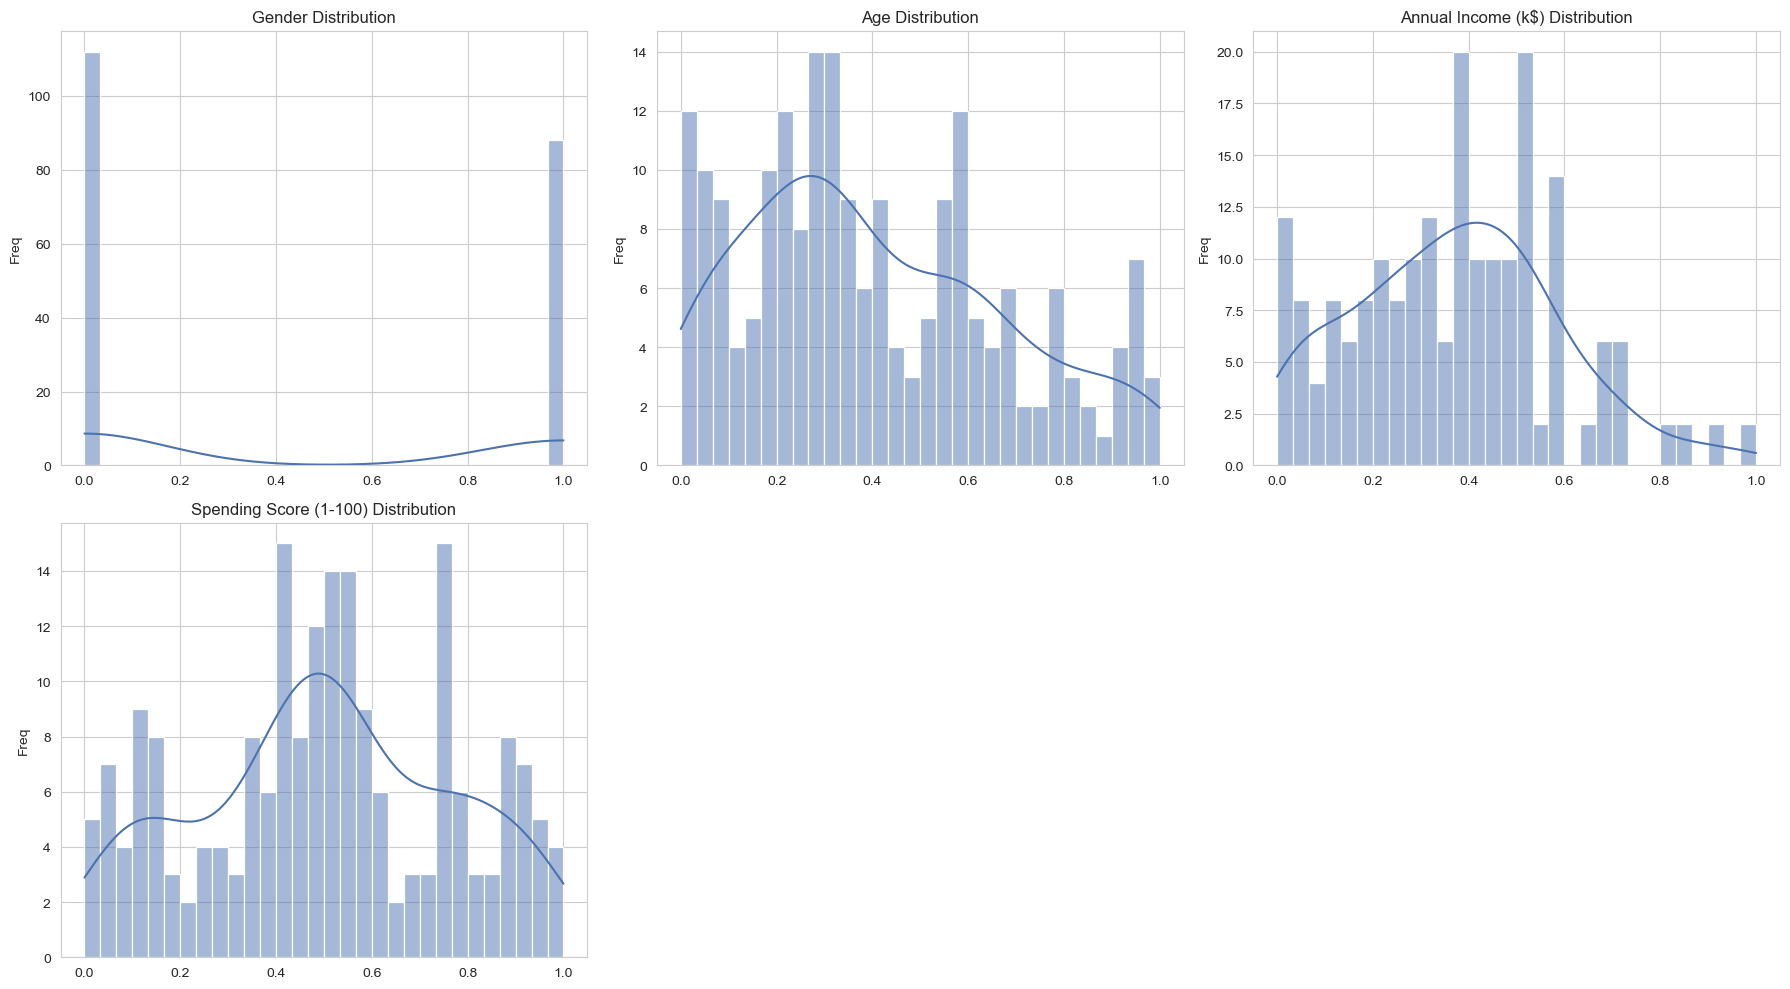

In [11]:
plot_histograms(df)

In [12]:
import scipy.cluster.hierarchy as sch

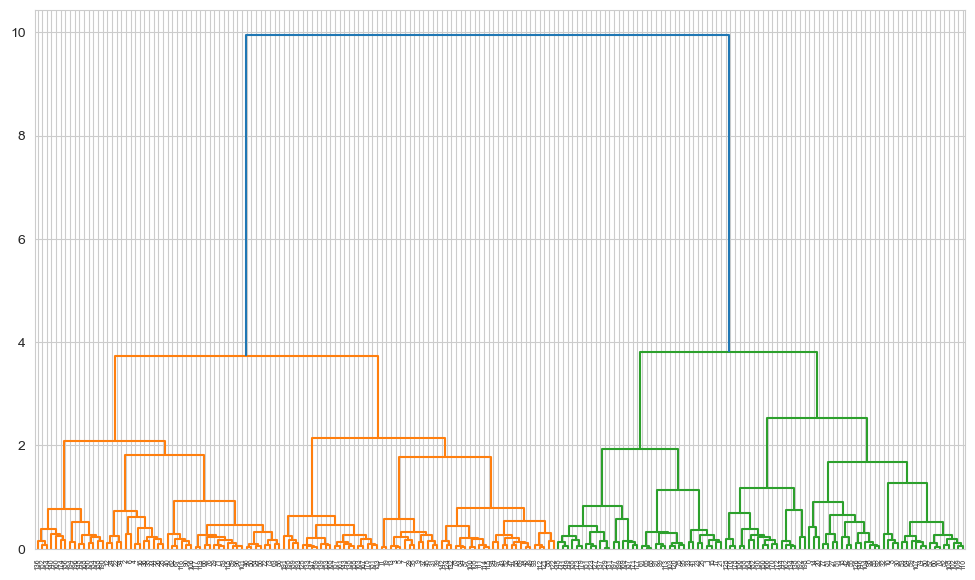

In [13]:
plt.figure(figsize = (12 , 7))
dendogram = sch.dendrogram(sch.linkage(df , method = 'ward'))
plt.show()

In [16]:
# 4 veya 6 küme seçebiliriz manuel olarak göz ile baktığımız zaman

In [15]:
from sklearn.cluster import AgglomerativeClustering

In [17]:
hc = AgglomerativeClustering(n_clusters = 4 , linkage = 'ward')

y_hc = hc.fit_predict(df)

y_hc

array([0, 2, 3, 1, 3, 1, 3, 1, 0, 1, 0, 1, 3, 1, 0, 2, 3, 2, 0, 1, 0, 2,
       3, 2, 3, 2, 3, 0, 3, 1, 0, 1, 0, 2, 3, 1, 3, 1, 3, 1, 3, 2, 0, 1,
       3, 1, 3, 1, 1, 1, 3, 0, 1, 0, 3, 0, 3, 0, 1, 0, 0, 2, 3, 3, 0, 2,
       3, 3, 2, 1, 0, 3, 3, 3, 0, 2, 3, 0, 1, 3, 0, 0, 0, 3, 1, 0, 3, 1,
       1, 3, 3, 2, 0, 1, 1, 2, 3, 1, 0, 2, 1, 3, 0, 2, 0, 1, 3, 0, 0, 0,
       0, 1, 1, 2, 1, 1, 3, 3, 3, 3, 2, 1, 1, 2, 1, 1, 0, 2, 0, 2, 0, 2,
       1, 1, 0, 1, 3, 2, 0, 1, 3, 2, 1, 1, 0, 2, 0, 1, 3, 2, 0, 2, 3, 1,
       3, 1, 0, 1, 0, 1, 3, 1, 0, 1, 0, 1, 0, 1, 3, 2, 0, 2, 0, 2, 3, 1,
       0, 2, 0, 2, 3, 1, 0, 1, 3, 2, 3, 2, 3, 1, 3, 1, 0, 1, 3, 1, 3, 2,
       0, 2])

In [18]:
df['Cluster'] = pd.DataFrame(data = y_hc , dtype = int)

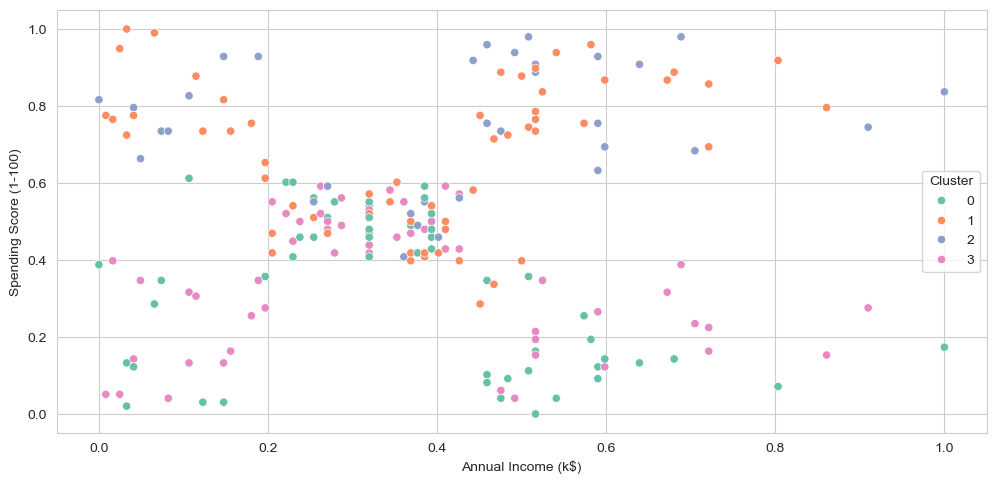

In [23]:
plt.figure(figsize = (12 , 5.5))
sns.scatterplot(data = df , x = 'Annual Income (k$)' , y = 'Spending Score (1-100)', hue = 'Cluster' , palette = 'Set2')
plt.show()

In [24]:
from sklearn.metrics import silhouette_score

print(silhouette_score(df , y_hc))

0.7143503785893516


In [25]:
# Farklı kolonlar ve farklı algoritmalar deneyerek yapmaya çalışalım

In [36]:
df = pd.read_csv('27-mall_customers.csv')

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

df.drop(inplace = True , columns = 'CustomerID' , axis = 1 )

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [42]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score , davies_bouldin_score , calinski_harabasz_score

feature_2d = ['Annual Income (k$)' , 'Spending Score (1-100)']
feature_3d = ['Age' , 'Annual Income (k$)' , 'Spending Score (1-100)']
feature_4d = ['Gender' , 'Age' , 'Annual Income (k$)' , 'Spending Score (1-100)']

for feats in [feature_2d , feature_3d , feature_4d] : 
    X = df[feats]
    X_scaled = MinMaxScaler().fit_transform(X)
    
    hc = AgglomerativeClustering(n_clusters = 5)
    y_hc = hc.fit_predict(X_scaled)

    sil = silhouette_score(df , y_hc)
    db = davies_bouldin_score(df , y_hc)
    ch = calinski_harabasz_score(df , y_hc)

    print('\n ----------------------')
    print(f'feature : {feats}')
    print('Silhouette : ' , sil)
    print('Davies - Bouldin : ', db)
    print('Calinski - Harabasz : ' , ch)


 ----------------------
feature : ['Annual Income (k$)', 'Spending Score (1-100)']
Silhouette :  0.4401678489662414
Davies - Bouldin :  0.8185574181506092
Calinski - Harabasz :  146.95997294982746

 ----------------------
feature : ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Silhouette :  0.37356468481077554
Davies - Bouldin :  1.0760618035407457
Calinski - Harabasz :  114.57528199058856

 ----------------------
feature : ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Silhouette :  -0.01592911160910434
Davies - Bouldin :  4.6864321202320625
Calinski - Harabasz :  30.9517286754789


In [44]:
import warnings
warnings.filterwarnings('ignore')

In [45]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score , davies_bouldin_score , calinski_harabasz_score
from sklearn.cluster import KMeans

feature_2d = ['Annual Income (k$)' , 'Spending Score (1-100)']
feature_3d = ['Age' , 'Annual Income (k$)' , 'Spending Score (1-100)']
feature_4d = ['Gender' , 'Age' , 'Annual Income (k$)' , 'Spending Score (1-100)']

for feats in [feature_2d , feature_3d , feature_4d] : 
    X = df[feats]
    X_scaled = MinMaxScaler().fit_transform(X)
    
    kmeans = KMeans(n_clusters = 5)
    y_hc = kmeans.fit_predict(X_scaled)

    sil = silhouette_score(df , y_hc)
    db = davies_bouldin_score(df , y_hc)
    ch = calinski_harabasz_score(df , y_hc)

    print('\n ----------------------')
    print(f'feature : {feats}')
    print('Silhouette : ' , sil)
    print('Davies - Bouldin : ', db)
    print('Calinski - Harabasz : ' , ch)


 ----------------------
feature : ['Annual Income (k$)', 'Spending Score (1-100)']
Silhouette :  0.44512364854575975
Davies - Bouldin :  0.8196121943141529
Calinski - Harabasz :  150.75536557183094

 ----------------------
feature : ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Silhouette :  0.389378409031856
Davies - Bouldin :  1.029760973925481
Calinski - Harabasz :  122.57683799550061

 ----------------------
feature : ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Silhouette :  -0.01894683143362923
Davies - Bouldin :  7.474631101355911
Calinski - Harabasz :  29.015053050922777
